## Name: Sharon Elango
## Batch : 3    Roll No : 62
## Expt.-8: Clustering of Countries with World Bank API

In [4]:
!pip install requests

In [5]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage

In [6]:
def fetch_indicator(code, year = "2022"):
    url = f"https://api.worldbank.org/v2/country/all/indicator/{code}?date={year}&format=json&per_page=30000"
    response = requests.get(url).json()[1]

    data = {}
    for item in response:
        country = item["country"]["value"]
        value=item["value"]
        if value is not None:
            data[country] = value

    return pd.Series(data, name=code)

In [7]:
gdp = fetch_indicator("NY.GDP.PCAP.CD")
pop = fetch_indicator("SP.POP.TOTL")
life = fetch_indicator("SP.DYN.LE00.IN")
lit = fetch_indicator("SE.ADT.LITR.ZS")

In [8]:
df=pd.concat ([gdp, pop, life, lit], axis=1)
df.columns=["GDP", "Population", "LifeExpectancy", "Literacy"]
df.dropna(inplace=True)
df.head()

,GDP,Population,LifeExpectancy,Literacy
Africa Eastern and Southern,1679.327622,731821393,64.487020,73.055977
Africa Western and Central,2138.473153,497387180,57.987813,60.780979
Arab World,7950.355820,471352066,71.876096,78.271927
Central Europe and the Baltics,19530.155323,100071871,76.652299,99.479919
Early-demographic dividend,4043.827763,3470644834,71.430455,81.242798


In [9]:
df.tail()

,GDP,Population,LifeExpectancy,Literacy
Uruguay,20818.614609,3390913,76.468,98.849998
Uzbekistan,2578.666894,34938955,72.147,100.000000
Viet Nam,4147.697772,99680655,74.502,96.129997
West Bank and Gaza,3799.955270,5043612,76.662,97.839996
Zambia,1447.123101,20152938,65.279,79.975143


In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

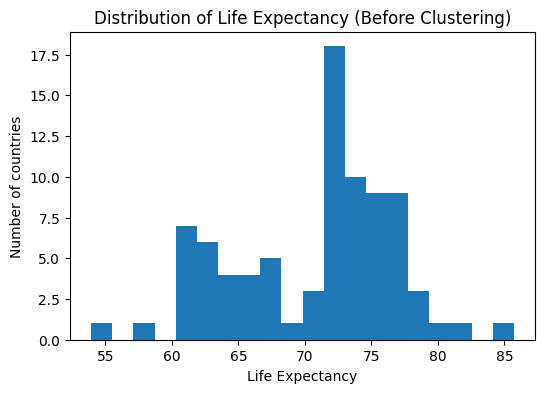

In [11]:
plt.figure(figsize=(6,4))
plt.hist(df["LifeExpectancy"], bins = 20)
plt.xlabel("Life Expectancy")
plt.ylabel("Number of countries")
plt.title("Distribution of Life Expectancy (Before Clustering)")
plt.show()

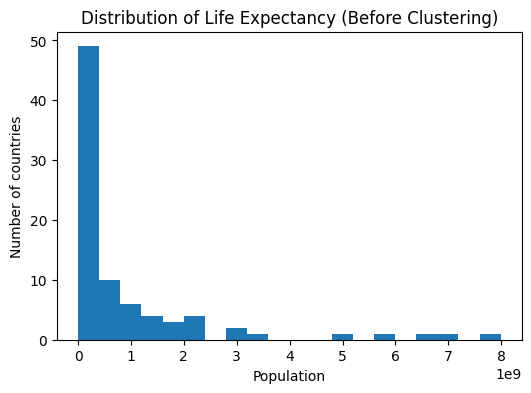

In [12]:
plt.figure(figsize=(6,4))
plt.hist(df["Population"], bins = 20)
plt.xlabel("Population")
plt.ylabel("Number of countries")
plt.title("Distribution of Life Expectancy (Before Clustering)")
plt.show()

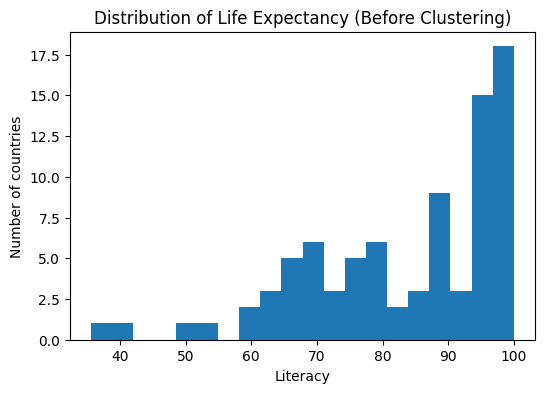

In [13]:
plt.figure(figsize=(6,4))
plt.hist(df["Literacy"], bins = 20)
plt.xlabel("Literacy")
plt.ylabel("Number of countries")
plt.title("Distribution of Life Expectancy (Before Clustering)")
plt.show()

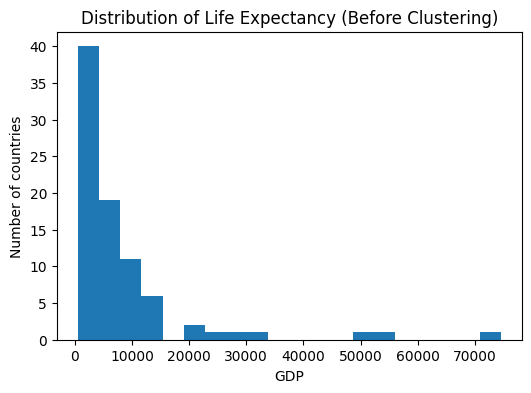

In [14]:
plt.figure(figsize=(6,4))
plt.hist(df["GDP"], bins = 20)
plt.xlabel("GDP")
plt.ylabel("Number of countries")
plt.title("Distribution of Life Expectancy (Before Clustering)")
plt.show()

In [15]:
country_name = "India"

result = df.loc[country_name]

print("Country:", country_name)
print("GDP per capita:", result["GDP"])
print("Population:", result["Population"])
print("Life Expectancy:", result["LifeExpectancy"])
print("Literacy Rate:", result["Literacy"])
#print("KMeans Cluster:", result["kMeansCluster"])
#print("Hierarchical Cluster:", result["Hierarchical Cluster"])

Country: India
GDP per capita: 2347.44829434623
Population: 1425423212.0
Life Expectancy: 71.698
Literacy Rate: 76.3199996948242


In [16]:
country_name = "Brazil"

result = df.loc[country_name]

print("Country:", country_name)
print("GDP per capita:", result["GDP"])
print("Population:", result["Population"])
print("Life Expectancy:", result["LifeExpectancy"])
print("Literacy Rate:", result["Literacy"])
#print("KMeans Cluster:", result["kMeansCluster"])
#print("Hierarchical Cluster:", result["Hierarchical Cluster"])

Country: Brazil
GDP per capita: 9281.33282136864
Population: 210306415.0
Life Expectancy: 74.872
Literacy Rate: 94.3853874531348


In [17]:
country_name = "Uruguay"

result = df.loc[country_name]

print("Country:", country_name)
print("GDP per capita:", result["GDP"])
print("Population:", result["Population"])
print("Life Expectancy:", result["LifeExpectancy"])
print("Literacy Rate:", result["Literacy"])
#print("KMeans Cluster:", result["kMeansCluster"])
#print("Hierarchical Cluster:", result["Hierarchical Cluster"])

Country: Uruguay
GDP per capita: 20818.6146091144
Population: 3390913.0
Life Expectancy: 76.468
Literacy Rate: 98.8499984741211


In [18]:
country_name = "Viet Nam"

result = df.loc[country_name]

print("Country:", country_name)
print("GDP per capita:", result["GDP"])
print("Population:", result["Population"])
print("Life Expectancy:", result["LifeExpectancy"])
print("Literacy Rate:", result["Literacy"])
#print("KMeans Cluster:", result["kMeansCluster"])
#print("Hierarchical Cluster:", result["Hierarchical Cluster"])

Country: Viet Nam
GDP per capita: 4147.69777213621
Population: 99680655.0
Life Expectancy: 74.502
Literacy Rate: 96.129997253418


In [19]:
country_name = "Uzbekistan"

result = df.loc[country_name]

print("Country:", country_name)
print("GDP per capita:", result["GDP"])
print("Population:", result["Population"])
print("Life Expectancy:", result["LifeExpectancy"])
print("Literacy Rate:", result["Literacy"])
#print("KMeans Cluster:", result["kMeansCluster"])
#print("Hierarchical Cluster:", result["Hierarchical Cluster"])

Country: Uzbekistan
GDP per capita: 2578.66689394219
Population: 34938955.0
Life Expectancy: 72.147
Literacy Rate: 100.0


In [20]:
import pandas as pd
# After removing dropna :
df=pd.concat([gdp, pop, life, lit], axis=1)
df.columns=["GDP", "Population", "LifeExpectancy", "Literacy"]
#df.dropna(inplace=True)
df.head()

,GDP,Population,LifeExpectancy,Literacy
Africa Eastern and Southern,1679.327622,731821393,64.487020,73.055977
Africa Western and Central,2138.473153,497387180,57.987813,60.780979
Arab World,7950.355820,471352066,71.876096,78.271927
Caribbean small states,17456.308485,4497310,72.832292,NaN
Central Europe and the Baltics,19530.155323,100071871,76.652299,99.479919


In [21]:
country_name = "United States"
result = df.loc[country_name]

print("Country:", country_name)
print("GDP per capita:", result["GDP"])
print("Population:", result["Population"])
print("Life Expectancy:", result["LifeExpectancy"])
print("Literacy Rate:", result["Literacy"])
#print("KMeans Cluster:", result["kMeansCluster"])
#print("Hierarchical Cluster:", result["Hierarchical Cluster"])

Country: United States
GDP per capita: 76657.2488844403
Population: 334017321.0
Life Expectancy: 77.4341463414634
Literacy Rate: nan


In [22]:
country_name = "Japan"
result = df.loc[country_name]

print("Country:", country_name)
print("GDP per capita:", result["GDP"])
print("Population:", result["Population"])
print("Life Expectancy:", result["LifeExpectancy"])
print("Literacy Rate:", result["Literacy"])
#print("KMeans Cluster:", result["kMeansCluster"])
#print("Hierarchical Cluster:", result["Hierarchical Cluster"])

Country: Japan
GDP per capita: 34065.6438962526
Population: 125124989.0
Life Expectancy: 83.9963414634146
Literacy Rate: nan


k	WCSS
1 	 336.00000000000006
2 	 206.43717192603808
3 	 142.06028324967596
4 	 122.46400641421171
5 	 68.71234707726028
6 	 56.092718405819106
7 	 51.08265517326418
8 	 41.70851027024395
9 	 31.213863029560223
10 	 27.04725098650771


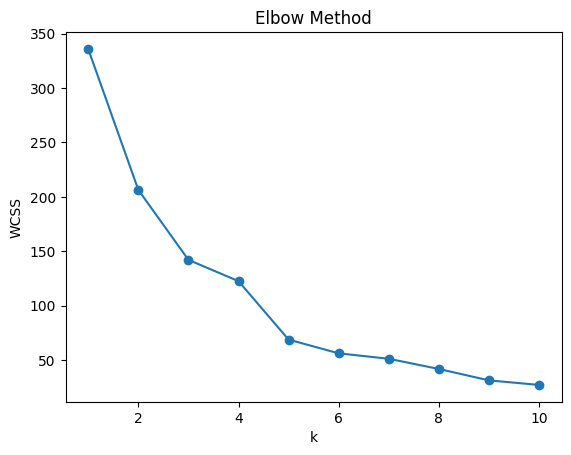

In [23]:
#Elbow Method to find optimal K
#This loop tests k values
WCSS = []
for k in range(1,11):
    km = KMeans(n_clusters=k, random_state=0)
    km.fit(X_scaled)
    WCSS.append(km.inertia_)

print("k\tWCSS")
for i in range(10):
    print(i+1, "\t", WCSS[i])

plt.plot(range(1,11), WCSS, marker='o')
plt.xlabel("k")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

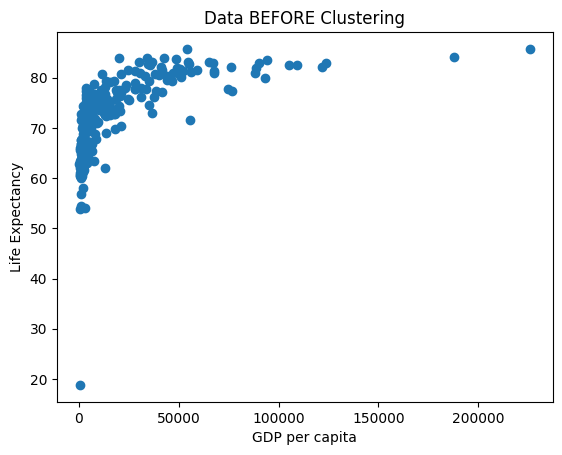

In [24]:
#Part-3: Clustering
plt.scatter(df["GDP"], df["LifeExpectancy"])
plt.xlabel("GDP per capita")
plt.ylabel("Life Expectancy")
plt.title("Data BEFORE Clustering")
plt.show()

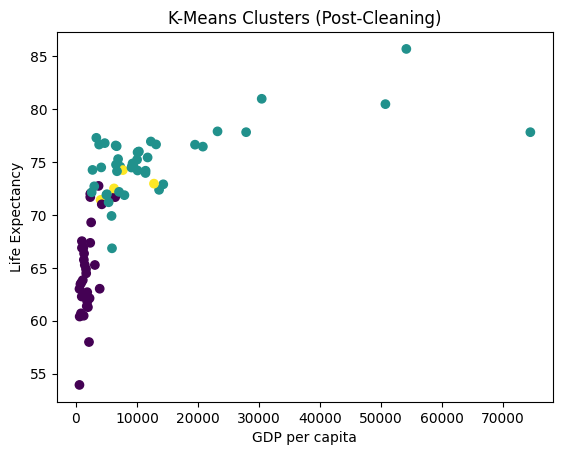

In [25]:
# 1. Re-create and CLEAN the dataframe
df = pd.concat([gdp, pop, life, lit], axis=1)
df.columns = ["GDP", "Population", "LifeExpectancy", "Literacy"]

# CRITICAL: You MUST drop NaNs for K-Means to work
df.dropna(inplace=True)

# 2. Scale the data AFTER cleaning
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# 3. Elbow Method
WCSS = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=0, n_init=10) # n_init avoids warnings
    km.fit(X_scaled)
    WCSS.append(km.inertia_)

# ... (Your plotting code for Elbow Method) ...

# 4. K-Means Clustering
km = KMeans(n_clusters=3, random_state=0, n_init=10)
labels_km = km.fit_predict(X_scaled)

# Add labels back to the cleaned dataframe
df["KMeansCluster"] = labels_km

# 5. Visualization
plt.scatter(df["GDP"], df["LifeExpectancy"], c=df["KMeansCluster"], cmap='viridis')
plt.xlabel("GDP per capita")
plt.ylabel("Life Expectancy")
plt.title("K-Means Clusters (Post-Cleaning)")
plt.show()

In [26]:
cluster_summary = df.groupby("KMeansCluster")[["GDP", "Population", "LifeExpectancy", "Literacy"]].mean()
print(cluster_summary)

                        GDP    Population  LifeExpectancy   Literacy
KMeansCluster                                                       
0               1915.596661  6.544831e+08       64.856833  68.564031
1              13280.490845  3.923248e+08       75.101970  94.739797
2               7094.638897  5.911254e+09       72.421619  86.116721


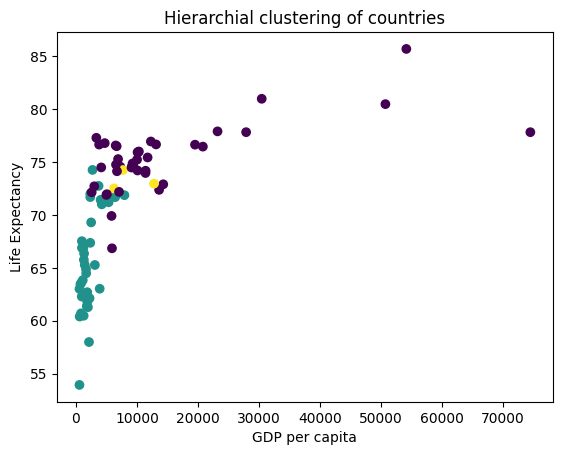

In [27]:
hc = AgglomerativeClustering(n_clusters = 3)
labels_hc = hc.fit_predict(X_scaled)
df["HierarchialCluster"] = labels_hc
plt.scatter(df["GDP"], df["LifeExpectancy"], c = labels_hc)
plt.xlabel("GDP per capita")
plt.ylabel("Life Expectancy")
plt.title("Hierarchial clustering of countries")
plt.show()